## Carregando o dataset

In [27]:
import pandas as pd

pd.set_option('display.max_columns', None)

# Carregar os datasets
df_treino = pd.read_csv('data/dados_treino.csv')
df_teste = pd.read_csv('data/dados_teste.csv')
print(f"Dimensões dataset treino:{df_treino.shape}")
print(f"Dimensões dataset teste:{df_teste.shape}")

Dimensões dataset treino:(16800, 47)
Dimensões dataset teste:(4200, 47)


In [28]:
df_teste.head()

,Unnamed: 0,NU_ANO,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_ENCERRA,TEMPO_DE_TRATAMENTO,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,TRATAMENTO_1,TRATAMENTO_2,TRATAMENTO_3,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,SITUACAO_AGRUPADA
0,57663,2023,1.0,1.0,74,0,210.0,210.0,0.0,True,False,True,False,False,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,0
1,21686,2019,15.0,15.0,24,0,541.0,540.0,1.0,False,True,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True,False,True,True,False,False,True,False,False,False,True,False,False,False,0
2,82766,2022,5.0,0.0,66,14,218.0,204.0,14.0,False,True,False,True,False,True,False,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,0
3,56499,2021,1.0,1.0,20,0,181.0,167.0,14.0,True,False,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,0
4,71079,2023,1.0,1.0,63,6,18.0,12.0,6.0,False,True,False,False,True,True,False,False,True,False,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,1


### Vamos remover a coluna de ID do dataset de treino e teste e fazer one-hot da coluna `NU_ANO`

In [29]:
# Removo a coluna de indexação
df_treino = df_treino.drop(columns=['Unnamed: 0'], errors='ignore')
df_teste = df_teste.drop(columns=['Unnamed: 0'], errors='ignore')

# faço one hot encoding da coluna NU_ANO
df_treino = pd.get_dummies(df_treino, columns=['NU_ANO'], prefix='ANO')
df_teste = pd.get_dummies(df_teste, columns=['NU_ANO'], prefix='ANO')
df_treino, df_teste = df_treino.align(df_teste, join='outer', axis=1, fill_value=0)

In [30]:
df_teste.head()

,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_ENCERRA,TEMPO_DE_TRATAMENTO,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,TRATAMENTO_1,TRATAMENTO_2,TRATAMENTO_3,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,SITUACAO_AGRUPADA,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023
0,1.0,1.0,74,0,210.0,210.0,0.0,True,False,True,False,False,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,False,False,True,False,False,False,True,False,0,False,False,False,False,True
1,15.0,15.0,24,0,541.0,540.0,1.0,False,True,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True,False,True,True,False,False,True,False,False,False,True,False,False,False,0,True,False,False,False,False
2,5.0,0.0,66,14,218.0,204.0,14.0,False,True,False,True,False,True,False,False,True,False,False,True,False,True,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,False,False,True,False,False,True,False,False,0,False,False,False,True,False
3,1.0,1.0,20,0,181.0,167.0,14.0,True,False,False,False,True,True,False,False,True,False,False,True,False,True,False,True,False,True,True,False,False,True,False,True,False,True,False,True,False,True,False,False,False,False,True,False,False,0,False,False,True,False,False
4,1.0,1.0,63,6,18.0,12.0,6.0,False,True,False,False,True,True,False,False,True,False,False,True,True,False,False,True,False,True,True,False,False,True,False,True,False,True,True,False,False,False,False,True,False,True,False,False,False,1,False,False,False,False,True


### Separação de Features

Para o treinamento do modelo, as variáveis foram separadas em três grupos:

- **Features Regressivas**: variáveis contínuas ou numéricas utilizadas como preditores principais.
- **Feature Alvo**: variável que será prevista pelo modelo. Neste caso, `SITUACAO_AGRUPADA`.
- **Features Classificativas**: variáveis categóricas já na forma de one-hot

In [31]:
features_regressivas = ["NU_CONTATO", "NU_COMU_EX", "IDADE_ANOS", "TEMPO_DE_NOTI", "TEMPO_DE_ENCERRA", "TEMPO_DE_TRATAMENTO", "TEMPO_DE_INICIO_TRATAMENTO"]
target = "SITUACAO_AGRUPADA"
features_classificativas = [col for col in df_treino.columns if col not in features_regressivas + [target]]

### Verificando se há interseção entre colunas:

In [32]:
# Transforma tudo em conjuntos
regressivas = set(features_regressivas)
classificativas = set(features_classificativas)
todas_colunas = set(df_treino.columns)
target_set = {target}

# Testa se não há interseção
sem_interseção = regressivas.isdisjoint(classificativas)

# Testa se a união cobre todas as colunas (exceto o target)
cobre_tudo = regressivas.union(classificativas, target_set) == todas_colunas

# Resultado final
if sem_interseção and cobre_tudo:
    print("Tudo certo: sem interseção e todas as colunas cobertas.")
else:
    print("Há sobreposição ou colunas faltando.")


Tudo certo: sem interseção e todas as colunas cobertas.


### Verificando se os datasets têm colunas iguais

In [33]:
df_treino.columns.equals(df_teste.columns)

True

## Lidando com dados ausentes

### Procurando as colunas com valores nulos em cada coluna

Porcentagem de valores nulos no treino (%):
NU_CONTATO                    0.88
NU_COMU_EX                    3.96
IDADE_ANOS                    0.00
TEMPO_DE_NOTI                 0.00
TEMPO_DE_ENCERRA              0.65
TEMPO_DE_TRATAMENTO           2.33
TEMPO_DE_INICIO_TRATAMENTO    1.70
CS_SEXO_F                     0.00
CS_SEXO_M                     0.00
CS_RACA_1                     0.00
CS_RACA_2                     0.00
CS_RACA_4                     0.00
TRATAMENTO_1                  0.00
TRATAMENTO_2                  0.00
TRATAMENTO_3                  0.00
FORMA_1                       0.00
FORMA_2                       0.00
AGRAVAIDS_1.0                 0.00
AGRAVAIDS_2.0                 0.00
AGRAVALCOO_1.0                0.00
AGRAVALCOO_2.0                0.00
AGRAVDIABE_1.0                0.00
AGRAVDIABE_2.0                0.00
AGRAVOUTRA_1.0                0.00
AGRAVOUTRA_2.0                0.00
TRATSUP_AT_1.0                0.00
TRATSUP_AT_2.0                0.00
POP_LIBER_1

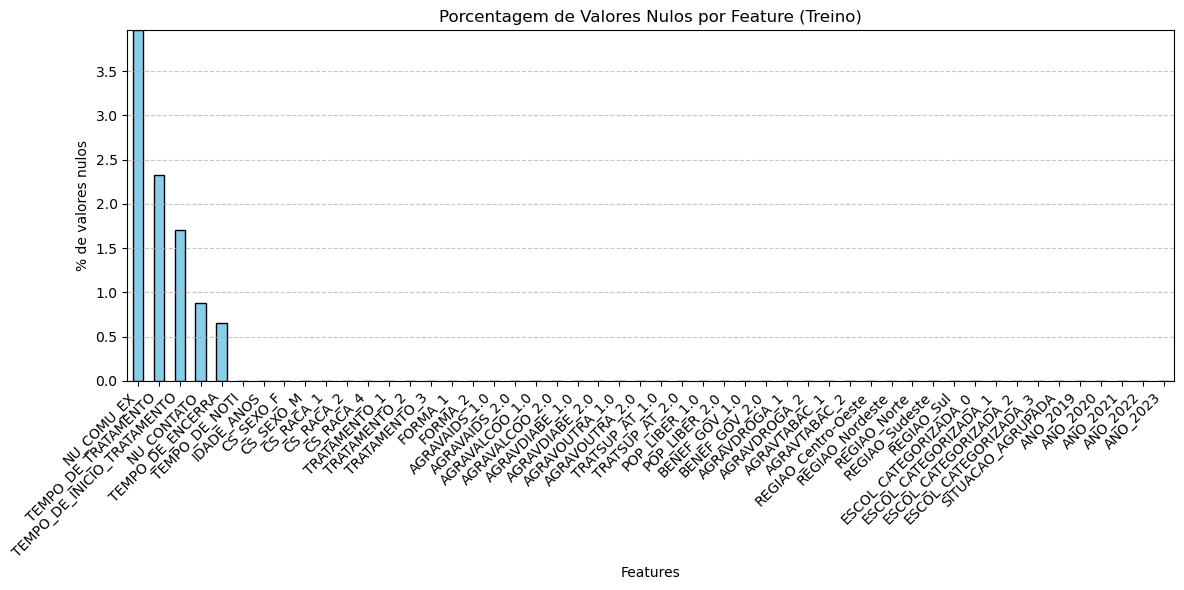

In [34]:
import matplotlib.pyplot as plt

# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))


# Plotando qtd de valores nulos
null_percent = (df_treino.isnull().sum() / len(df_treino) * 100).round(2)
null_percent = null_percent.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
null_percent.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Porcentagem de Valores Nulos por Feature (Treino)')
plt.ylabel('% de valores nulos')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, max(null_percent.max(), 1))  # Garantir alguma altura mínima visível
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como todas as colunas apresentam **menos de 5% de valores faltantes**, **nenhuma será removida**. Em vez disso, optamos por **imputar os valores ausentes com base na estrutura dos dados**, de forma a preservar a informação e reduzir viés:

* **Features Classificativas:** preenchidas com a moda dos valores da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.
* **Features Regressivas:** preenchidas com a média por grupo da feture dentre aquelas do mesmo grupo da `SITUACAO_AGRUPADA`.

> **Observação:** não há casos com valores nulos na variável alvo `SITUACAO_AGRUPADA`.


In [35]:
# Transformar classificações: True/False → 1/0 (sem alterar NaNs)
for col in features_classificativas:
    df_treino[col] = df_treino[col].apply(lambda x: int(x) if pd.notnull(x) else x)
    df_teste[col] = df_teste[col].apply(lambda x: int(x) if pd.notnull(x) else x)

# Transformar colunas de regressão: int → float (sem alterar NaNs)
for col in features_regressivas:
    df_treino[col] = df_treino[col].astype(float)
    df_teste[col] = df_teste[col].astype(float)

# Obter a lista de colunas com valores nulos
colunas_com_nulos = df_treino.columns[df_treino.isnull().any()].tolist()

for col in colunas_com_nulos:
    if col in features_classificativas:  # Coluna categórica (binária)
        modos = df_treino.groupby('SITUACAO_AGRUPADA')[col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 0)
        df_treino[col] = df_treino.apply(
            lambda row: modos[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: modos.get(row['SITUACAO_AGRUPADA'], 0) if pd.isnull(row[col]) else row[col], axis=1
        )

    elif col in features_regressivas:  # Coluna numérica (regressiva)
        medias = df_treino.groupby('SITUACAO_AGRUPADA')[col].mean()
        media_global = df_treino[col].mean()
        df_treino[col] = df_treino.apply(
            lambda row: medias[row['SITUACAO_AGRUPADA']] if pd.isnull(row[col]) else row[col], axis=1
        )
        df_teste[col] = df_teste.apply(
            lambda row: medias.get(row['SITUACAO_AGRUPADA'], media_global) if pd.isnull(row[col]) else row[col], axis=1
        )


In [36]:
# Percentual de valores nulos no dataset de treino
print("Porcentagem de valores nulos no treino (%):")
print((df_treino.isnull().sum() / len(df_treino) * 100).round(2))

# Percentual de valores nulos no dataset de teste
print("\nPorcentagem de valores nulos no teste (%):")
print((df_teste.isnull().sum() / len(df_teste) * 100).round(2))

Porcentagem de valores nulos no treino (%):
NU_CONTATO                    0.0
NU_COMU_EX                    0.0
IDADE_ANOS                    0.0
TEMPO_DE_NOTI                 0.0
TEMPO_DE_ENCERRA              0.0
TEMPO_DE_TRATAMENTO           0.0
TEMPO_DE_INICIO_TRATAMENTO    0.0
CS_SEXO_F                     0.0
CS_SEXO_M                     0.0
CS_RACA_1                     0.0
CS_RACA_2                     0.0
CS_RACA_4                     0.0
TRATAMENTO_1                  0.0
TRATAMENTO_2                  0.0
TRATAMENTO_3                  0.0
FORMA_1                       0.0
FORMA_2                       0.0
AGRAVAIDS_1.0                 0.0
AGRAVAIDS_2.0                 0.0
AGRAVALCOO_1.0                0.0
AGRAVALCOO_2.0                0.0
AGRAVDIABE_1.0                0.0
AGRAVDIABE_2.0                0.0
AGRAVOUTRA_1.0                0.0
AGRAVOUTRA_2.0                0.0
TRATSUP_AT_1.0                0.0
TRATSUP_AT_2.0                0.0
POP_LIBER_1.0                 0.0
POP_

## Normalizando as features regresssivas

In [37]:
df_teste.head()

,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_ENCERRA,TEMPO_DE_TRATAMENTO,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,TRATAMENTO_1,TRATAMENTO_2,TRATAMENTO_3,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,SITUACAO_AGRUPADA,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023
0,1.0,1.0,74.0,0.0,210.0,210.0,0.0,1,0,1,0,0,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1
1,15.0,15.0,24.0,0.0,541.0,540.0,1.0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0
2,5.0,0.0,66.0,14.0,218.0,204.0,14.0,0,1,0,1,0,1,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0
3,1.0,1.0,20.0,0.0,181.0,167.0,14.0,1,0,0,0,1,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0
4,1.0,1.0,63.0,6.0,18.0,12.0,6.0,0,1,0,0,1,1,0,0,1,0,0,1,1,0,0,1,0,1,1,0,0,1,0,1,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1


Decidimos aplicar a **normalização z-score** (também chamada de padronização) às features regressivas para garantir que todas as variáveis numéricas estejam na mesma escala. Essa normalização evita que variáveis com médias ou desvios padrões muito distintos tenham influência desproporcional no treinamento do modelo.

A normalização foi feita utilizando apenas as médias e desvios padrões calculados no conjunto de treino, sendo aplicada tanto ao conjunto de treino quanto ao de teste. Essa prática é importante para evitar **vazamento de informação (data leakage)**, garantindo que o modelo não tenha acesso a informações do conjunto de teste durante o treinamento.


In [38]:
medias = df_treino[features_regressivas].mean()
desvios = df_treino[features_regressivas].std()

df_treino[features_regressivas] = (df_treino[features_regressivas] - medias) / desvios

df_teste[features_regressivas] = (df_teste[features_regressivas] - medias) / desvios

## Separação da variável alvo do restante dos dados de treino e teste

In [39]:
X_treino = df_treino.drop(columns=[target])
y_treino = df_treino[target]

X_teste = df_teste.drop(columns=[target])
y_teste = df_teste[target]

In [40]:
X_treino.head()

,NU_CONTATO,NU_COMU_EX,IDADE_ANOS,TEMPO_DE_NOTI,TEMPO_DE_ENCERRA,TEMPO_DE_TRATAMENTO,TEMPO_DE_INICIO_TRATAMENTO,CS_SEXO_F,CS_SEXO_M,CS_RACA_1,CS_RACA_2,CS_RACA_4,TRATAMENTO_1,TRATAMENTO_2,TRATAMENTO_3,FORMA_1,FORMA_2,AGRAVAIDS_1.0,AGRAVAIDS_2.0,AGRAVALCOO_1.0,AGRAVALCOO_2.0,AGRAVDIABE_1.0,AGRAVDIABE_2.0,AGRAVOUTRA_1.0,AGRAVOUTRA_2.0,TRATSUP_AT_1.0,TRATSUP_AT_2.0,POP_LIBER_1.0,POP_LIBER_2.0,BENEF_GOV_1.0,BENEF_GOV_2.0,AGRAVDROGA_1,AGRAVDROGA_2,AGRAVTABAC_1,AGRAVTABAC_2,REGIAO_Centro-Oeste,REGIAO_Nordeste,REGIAO_Norte,REGIAO_Sudeste,REGIAO_Sul,ESCOL_CATEGORIZADA_0,ESCOL_CATEGORIZADA_1,ESCOL_CATEGORIZADA_2,ESCOL_CATEGORIZADA_3,ANO_2019,ANO_2020,ANO_2021,ANO_2022,ANO_2023
0,-0.234152,-0.136932,0.455051,-0.221317,0.423421,0.571779,-0.190080,0,1,0,0,1,1,0,0,1,0,0,1,0,1,1,0,0,1,1,0,0,1,0,1,0,1,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0
1,0.127986,0.269047,0.629336,-0.221317,2.335625,2.649918,-0.056192,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0
2,-0.415221,-0.542912,-1.113518,-0.221317,0.119896,0.231101,-0.190080,0,1,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0
3,-0.415221,-0.339922,-0.183996,-0.201205,2.881969,3.319919,-0.167765,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0
4,-0.234152,-0.136932,1.442669,-0.221317,-1.913718,-2.051445,-0.190080,0,1,0,1,0,1,0,0,1,0,0,1,0,1,1,0,1,0,0,1,0,1,0,1,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0


In [41]:
print("X_treino shape:", X_treino.shape)
print("y_treino shape:", y_treino.shape)
print("X_teste shape:", X_teste.shape)
print("y_teste shape:", y_teste.shape)


X_treino shape: (16800, 49)
y_treino shape: (16800,)
X_teste shape: (4200, 49)
y_teste shape: (4200,)


## Lidando com desbalanceio de classes

Fomos orientados a procurar resolver o problema de desbalanceamento de classes quando `n_maj > 1.5⋅n_min`

In [42]:
from collections import Counter

# Conta as amostras por classe no y_treino
classe_counts = Counter(y_treino)
n_maj = max(classe_counts.values())
n_min = min(classe_counts.values())

# Verifica a condição
desbalanceado = n_maj > 1.5 * n_min
print(f"Desbalanceado? {desbalanceado} (n_maj = {n_maj}, n_min = {n_min})")

Desbalanceado? True (n_maj = 14782, n_min = 2018)


Como está desbalanceado pelo critério dado, vamos aplicar o SMOTE (Synthetic Minority Over-sampling Technique), uma técnica que balanceia as classes pela adição de exemplos sintéticos da classe minoritária. Vizinhos esses gerados por KNN.

In [43]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)
X_treino_res, y_treino_res = oversampler.fit_resample(X_treino, y_treino)

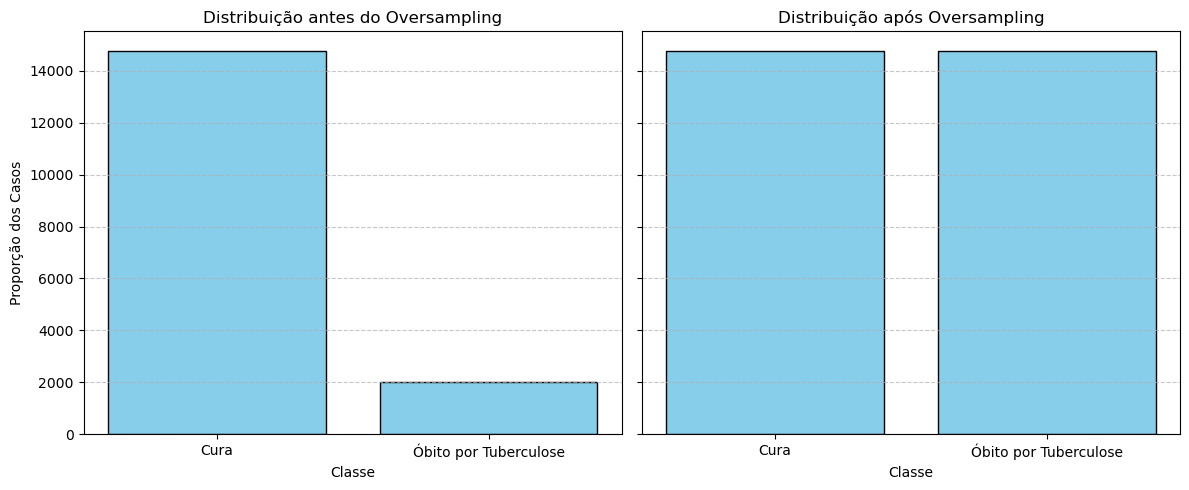

In [44]:
#plotando valores antes e depois do oversampling
y_treino_series = pd.Series(y_treino)
y_treino_res_series = pd.Series(y_treino_res)

proporcao_before = y_treino_series.value_counts(normalize=False).sort_index()
proporcao_after = y_treino_res_series.value_counts(normalize=False).sort_index()

labelnames = {0: 'Cura', 1: 'Óbito por Tuberculose'}

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

proporcao_before.index = proporcao_before.index.map(labelnames)
axs[0].bar(proporcao_before.index, proporcao_before.values, color='skyblue', edgecolor='black')
axs[0].set_title('Distribuição antes do Oversampling')
axs[0].set_xlabel('Classe')
axs[0].set_ylabel('Proporção dos Casos')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)

proporcao_after.index = proporcao_after.index.map(labelnames)
axs[1].bar(proporcao_after.index, proporcao_after.values, color='skyblue', edgecolor='black')
axs[1].set_title('Distribuição após Oversampling')
axs[1].set_xlabel('Classe')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Treinar e validar (TODO: explicar via markdown o resto)

- **Grid Search com Cross-Validation**:
  - Realiza validação cruzada estratificada (5-folds) para encontrar os melhores hiperparâmetros do modelo informado, testando todas as combinações possíveis entre os hiperparâmetros propostos.
  - Utiliza a métrica `recall macro` para otimizar o modelo, tratando de forma equilibrada as classes mesmo em contextos desbalanceados e evitando **casos falsos negativos**, que são críticos ao predizer óbitos.

> **Obs.:** A matriz de confusão é normalizada por linha (ou seja, por classe real), o que permite visualizar a proporção de exemplos de cada classe que foram corretamente ou incorretamente classificados. Isso é especialmente útil em conjuntos de dados desbalanceados, pois destaca o desempenho do modelo na classe minoritária sem ser ofuscado pela quantidade absoluta de exemplos da classe majoritária.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def plot_matriz_confusao_normalizada(y_verdadeiro, y_predito, nome_modelo):
    # Matriz de confusão normalizada por linha
    cm = confusion_matrix(y_verdadeiro, y_predito)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Nomes das classes
    labels = ['Classe 0', 'Classe 1']
    cm_df = pd.DataFrame(cm_percent, index=labels, columns=labels)

    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt=".2%", cmap="Blues")
    plt.title(f"Matriz de Confusão Normalizada - {nome_modelo}")
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.show()
    
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

def avaliar_modelo(modelo, params, nome, scoring='f1_macro'):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(modelo, params, cv=cv, scoring=scoring, n_jobs=-1)
    grid.fit(X_treino_res, y_treino_res)

    print(f"\nModelo: {nome}")
    print("Melhores hiperparâmetros:", grid.best_params_)

    y_pred = grid.predict(X_teste)
    print("\nRelatório no conjunto de teste:")
    print(classification_report(y_teste, y_pred, digits=4))

    # Chama a função de plot
    plot_matriz_confusao_normalizada(y_teste, y_pred, nome)

    return grid.best_estimator_, grid.best_score_



Modelo: kNN
Melhores hiperparâmetros: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}

Relatório no conjunto de teste:
              precision    recall  f1-score   support

           0     0.9544    0.9737    0.9640      3695
           1     0.7744    0.6594    0.7123       505

    accuracy                         0.9360      4200
   macro avg     0.8644    0.8166    0.8381      4200
weighted avg     0.9327    0.9360    0.9337      4200



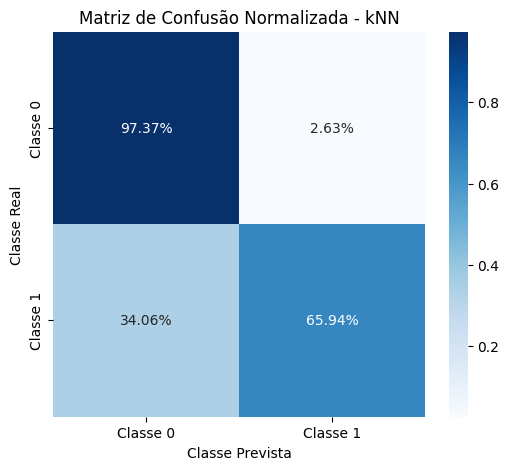

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
params_knn = {
    'n_neighbors': [1, 5, 10],
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}
knn_best, score_knn = avaliar_modelo(knn, params_knn, "kNN", scoring='recall_macro')



Modelo: Regressão Logística
Melhores hiperparâmetros: {'class_weight': 'balanced'}

Relatório no conjunto de teste:
              precision    recall  f1-score   support

           0     0.9843    0.9510    0.9674      3695
           1     0.7127    0.8891    0.7912       505

    accuracy                         0.9436      4200
   macro avg     0.8485    0.9201    0.8793      4200
weighted avg     0.9517    0.9436    0.9462      4200



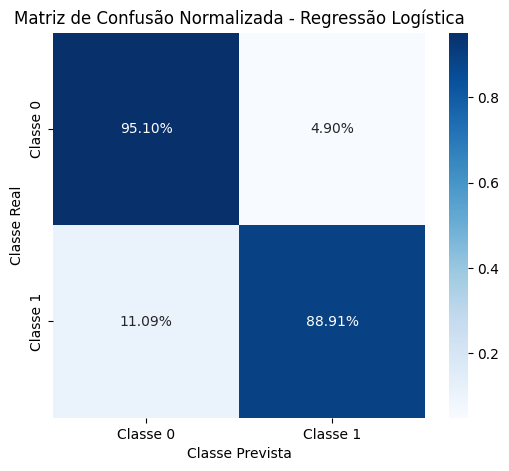

In [22]:
from sklearn.linear_model import LogisticRegression

log = LogisticRegression(max_iter=1000)
params_log = {
    'class_weight': ['balanced', {0: 1, 1: 2}]
}
log_best, score_log = avaliar_modelo(log, params_log, "Regressão Logística", scoring='recall_macro')



Modelo: Random Forest
Melhores hiperparâmetros: {'max_depth': 50, 'min_samples_split': 2, 'n_estimators': 100}

Relatório no conjunto de teste:
              precision    recall  f1-score   support

           0     0.9769    0.9732    0.9751      3695
           1     0.8092    0.8317    0.8203       505

    accuracy                         0.9562      4200
   macro avg     0.8931    0.9024    0.8977      4200
weighted avg     0.9567    0.9562    0.9564      4200



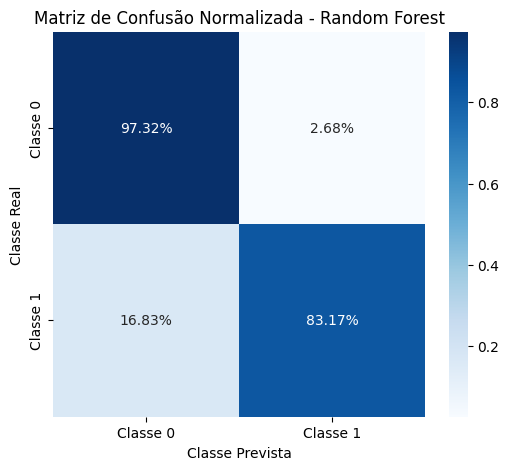

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
params_rf = {
    'n_estimators': [10, 100, 200],
    'max_depth': [10, 50],
    'min_samples_split': [2, 10, 30],
}
rf_best, score_rf = avaliar_modelo(rf, params_rf, "Random Forest", scoring='recall')
